In [1]:
import pandas as pd
# pd.set_option('display.max_rows', None)  # Показывать все строки
pd.set_option('display.max_columns', None)  # Показывать все столбцы

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import KNNImputer

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from feature_engine.encoding import OneHotEncoder

from sklearn.preprocessing import QuantileTransformer

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import mutual_info_regression,f_regression, SelectKBest

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_features = [
    "1stFlrSF",
    "2ndFlrSF",
    'BsmtUnfSF',
    "BsmtFinSF1",
    "Fireplaces",
    "FullBath",
    "GarageCars",
    "GarageYrBlt",
    "GrLivArea",
    "LotArea",
    'MasVnrArea',
    "OpenPorchSF",
    "TotalBsmtSF",
    "YearBuilt",
    "YearRemodAdd",
    "BsmtExposure",
    "BsmtQual",
    "CentralAir",
    "ExterQual",
    "FireplaceQu",
    "Foundation",
    "GarageFinish",
    "GarageType",
    "HeatingQC",
    "KitchenQual",
    "LotShape",
    "MasVnrType",
    "OverallQual",
    "PavedDrive",
    "RoofStyle",
    "BsmtFinType1",
    "Exterior1st",
    "LandContour",
    "MSSubClass",
    "MSZoning",
    "Neighborhood",
    "OverallCond",
    "PoolQC",
    "SaleCondition",
    "SaleType",
    'SalePrice'
]

In [3]:
data = (pd.read_csv('../houseprice.csv', index_col='Id'))
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Numerical to categorical conversation function
def num_to_cat(data, features):
    for feat in features:
        data[feat] = data[feat].astype('str')
    return data

In [5]:
# Convert features
to_convert = ['MSSubClass', 'OverallQual', 'OverallCond', 'MoSold']
data = num_to_cat(data, to_convert)

In [6]:
data[to_convert].dtypes

MSSubClass     object
OverallQual    object
OverallCond    object
MoSold         object
dtype: object

In [7]:
data = data[final_features]
data.shape

(1460, 41)

In [8]:
numerical = data.select_dtypes(include=['number']).drop(columns=['SalePrice']).columns
categorical = data.select_dtypes(exclude=['number']).columns

# Missing Value Imputation

In [9]:
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(data["YearBuilt"])

data[numerical] = data[numerical].fillna(0)

data[categorical] = data[categorical].fillna('no_option')

## Outliers

In [10]:
data.drop(data[data.TotalBsmtSF > 5000].index, axis=0, inplace=True)
data.drop(data[data['1stFlrSF'] > 4000].index, axis=0, inplace=True)
data.drop(data[(data.GrLivArea > 4000) & (data.SalePrice < 200000)].index, axis=0, inplace=True)

## Encoding

In [11]:
neighborhood_map = {
    # Дорогие
    'NoRidge': 'Expensive',
    'NridgHt': 'Expensive',
    'StoneBr': 'Expensive',

    # Выше среднего
    'Timber': 'Above_Average',
    'Veenker': 'Above_Average',
    'Somerst': 'Above_Average',
    'ClearCr': 'Above_Average',
    'Crawfor': 'Above_Average',

    # Средний сегмент
    'CollgCr': 'Average',
    'Blmngtn': 'Average',
    'Gilbert': 'Average',
    'NWAmes': 'Average',
    'SawyerW': 'Average',

    # Ниже среднего
    'Mitchel': 'Below_Average',
    'NAmes': 'Below_Average',
    'NPkVill': 'Below_Average',
    'SWISU': 'Below_Average',
    'Blueste': 'Below_Average',
    'Sawyer': 'Below_Average',

    # Дешевые
    'OldTown': 'Cheap',
    'Edwards': 'Cheap',
    'BrkSide': 'Cheap',
    'BrDale': 'Cheap',
    'IDOTRR': 'Cheap',
    'MeadowV': 'Cheap'
}

In [12]:
data['Neighborhood'] = data['Neighborhood'].map(neighborhood_map)

In [13]:
ordinal_cols = [
    'Neighborhood',
    'OverallQual',
    'OverallCond',     
    'ExterQual',  
    'BsmtQual',     
    'BsmtExposure',
    'BsmtFinType1',
    'HeatingQC',  
    'KitchenQual',
    'FireplaceQu',
    'GarageFinish',  
    'PoolQC',     
    'LotShape',
    'PavedDrive',
]

nominal_cols = [
    'MSSubClass',
    'MSZoning',
    'LandContour',
    'RoofStyle',
    'Exterior1st',
    'MasVnrType',        
    'Foundation',                  
    'CentralAir',              
    'GarageType',             
    'SaleType',         
    'SaleCondition'   
]

In [14]:
# Кодируем номинальные признаки
ohe_encoder = OneHotEncoder(variables=nominal_cols, drop_last=False)
data = ohe_encoder.fit_transform(data)

In [15]:
# Кодируем ординальные признаки
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
data[ordinal_cols] = ordinal_encoder.fit_transform(data[ordinal_cols])

In [16]:
data.head()

,1stFlrSF,2ndFlrSF,BsmtUnfSF,BsmtFinSF1,Fireplaces,FullBath,GarageCars,GarageYrBlt,GrLivArea,LotArea,MasVnrArea,OpenPorchSF,TotalBsmtSF,YearBuilt,YearRemodAdd,BsmtExposure,BsmtQual,ExterQual,FireplaceQu,GarageFinish,HeatingQC,KitchenQual,LotShape,OverallQual,PavedDrive,BsmtFinType1,Neighborhood,OverallCond,PoolQC,SalePrice,MSSubClass_60,MSSubClass_20,MSSubClass_70,MSSubClass_50,MSSubClass_190,MSSubClass_45,MSSubClass_90,MSSubClass_120,MSSubClass_30,MSSubClass_85,MSSubClass_80,MSSubClass_160,MSSubClass_75,MSSubClass_180,MSSubClass_40,MSZoning_RL,MSZoning_RM,MSZoning_C (all),MSZoning_FV,MSZoning_RH,LandContour_Lvl,LandContour_Bnk,LandContour_Low,LandContour_HLS,RoofStyle_Gable,RoofStyle_Hip,RoofStyle_Gambrel,RoofStyle_Mansard,RoofStyle_Flat,RoofStyle_Shed,Exterior1st_VinylSd,Exterior1st_MetalSd,Exterior1st_Wd Sdng,Exterior1st_HdBoard,Exterior1st_BrkFace,Exterior1st_WdShing,Exterior1st_CemntBd,Exterior1st_Plywood,Exterior1st_AsbShng,Exterior1st_Stucco,Exterior1st_BrkComm,Exterior1st_AsphShn,Exterior1st_Stone,Exterior1st_ImStucc,Exterior1st_CBlock,MasVnrType_BrkFace,MasVnrType_no_option,MasVnrType_Stone,MasVnrType_BrkCmn,Foundation_PConc,Foundation_CBlock,Foundation_BrkTil,Foundation_Wood,Foundation_Slab,Foundation_Stone,CentralAir_Y,CentralAir_N,GarageType_Attchd,GarageType_Detchd,GarageType_BuiltIn,GarageType_CarPort,GarageType_no_option,GarageType_Basment,GarageType_2Types,SaleType_WD,SaleType_New,SaleType_COD,SaleType_ConLD,SaleType_ConLI,SaleType_CWD,SaleType_ConLw,SaleType_Con,SaleType_Oth,SaleCondition_Normal,SaleCondition_Abnorml,SaleCondition_Partial,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,856,854,150,706,0,2,2,2003.0,1710,8450,196.0,61,856,2003,2003,3.0,2.0,2.0,5.0,1.0,0.0,2.0,3.0,7.0,2.0,2.0,1.0,4.0,3.0,208500,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,1262,0,284,978,1,2,2,1976.0,1262,9600,0.0,0,1262,1976,1976,1.0,2.0,3.0,4.0,1.0,0.0,3.0,3.0,6.0,2.0,0.0,0.0,7.0,3.0,181500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,920,866,434,486,1,2,2,2001.0,1786,11250,162.0,42,920,2001,2002,2.0,2.0,2.0,4.0,1.0,0.0,2.0,0.0,7.0,2.0,2.0,1.0,4.0,3.0,223500,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,961,756,540,216,1,1,3,1998.0,1717,9550,0.0,35,756,1915,1970,3.0,3.0,3.0,2.0,2.0,2.0,2.0,0.0,7.0,2.0,0.0,0.0,4.0,3.0,140000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
5,1145,1053,490,655,1,2,3,2000.0,2198,14260,350.0,84,1145,2000,2000,0.0,2.0,2.0,4.0,1.0,0.0,2.0,0.0,8.0,2.0,2.0,4.0,4.0,3.0,250000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


# Normalizing Variables

In [17]:
# Применим логарифмирование к датасету

In [18]:
data['SalePrice'] = np.log1p(data['SalePrice'])

# Final top Features Data

In [19]:
enginedata = data.copy()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    enginedata.drop('SalePrice', axis=1),
    enginedata['SalePrice'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((1020, 108), (438, 108))

In [21]:
scaler = RobustScaler()
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

In [22]:
# --- Метрики ---
def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{label} R²: {r2:.4f}")
    print(f"{label} MAE: {mae:.2f}")
    print(f"{label} MSE: {mse:.2f}")
    print(f"{label} RMSE: {rmse:.2f}")

# Linear Regression

In [23]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train, y_train)

# --- Предсказания ---
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# --- Обратное логарифмирование ---
MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

print_metrics(y_train_exp, y_train_pred_exp, "Train")
print_metrics(y_test_exp, y_test_pred_exp, "Test")


Train R²: 0.9309
Train MAE: 13648.63
Train MSE: 421598536.51
Train RMSE: 20532.86

Test R²: 0.8724
Test MAE: 18060.88
Test MSE: 868718365.14
Test RMSE: 29474.03


# Lasso Regression

In [24]:
lasso = Lasso(alpha=0.001,
              max_iter=100000,
              random_state=0)
lasso.fit(X_train, y_train)

# --- Предсказания ---
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

# --- Обратное логарифмирование ---
MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

print_metrics(y_train_exp, y_train_pred_exp, "Train")
print_metrics(y_test_exp, y_test_pred_exp, "Test")


Train R²: 0.9186
Train MAE: 14613.62
Train MSE: 496643136.09
Train RMSE: 22285.49

Test R²: 0.8898
Test MAE: 17010.65
Test MSE: 749988588.75
Test RMSE: 27385.92


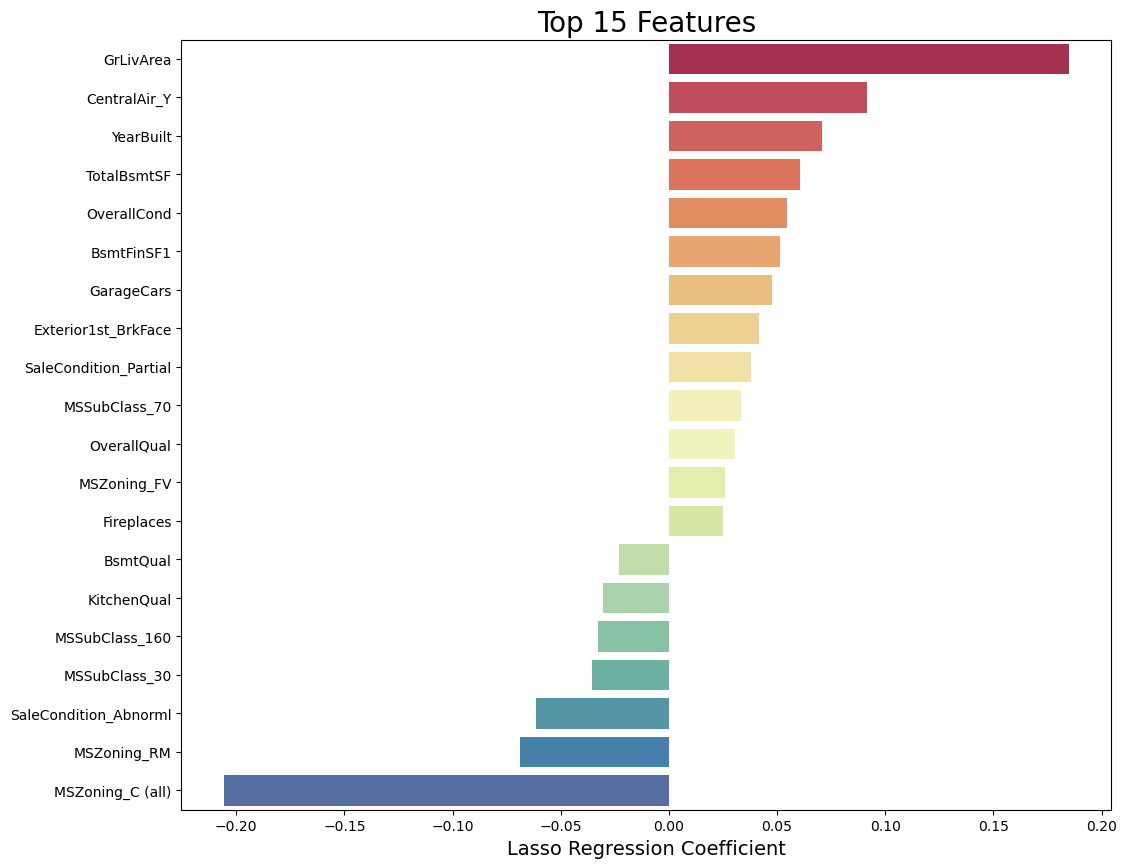

In [25]:
# Create dataframe of features, coefficients and absolute coefficients
lasso_df = pd.DataFrame(columns=['Feature', 'Coef', 'Abs Coef'])
lasso_df['Abs Coef'] = abs(lasso.coef_)
lasso_df['Coef'] = lasso.coef_
lasso_df['Feature'] = [col for col in data._get_numeric_data().columns if col !='SalePrice']

plt.figure(figsize=(12,10))
data = lasso_df.sort_values(by='Abs Coef', ascending=False).head(20)[['Feature', 'Coef']] \
               .sort_values(by='Coef', ascending=False).reset_index(drop=True)
    
ax = sns.barplot(data=data, y='Feature', x='Coef', orient='h', hue='Feature', palette='Spectral', legend=False)
ax.set_ylabel('')
ax.set_xlabel('Lasso Regression Coefficient', fontsize=14)
plt.title('Top 15 Features', fontsize=20);

## RandomForest

In [26]:
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

# --- Предсказания ---
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# --- Обратное логарифмирование ---
MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

print_metrics(y_train_exp, y_train_pred_exp, "Train")
print_metrics(y_test_exp, y_test_pred_exp, "Test")


Train R²: 0.9821
Train MAE: 6143.29
Train MSE: 109476046.14
Train RMSE: 10463.08

Test R²: 0.8992
Test MAE: 16745.25
Test MSE: 686068170.35
Test RMSE: 26192.90


## XGBoost

In [27]:
xgb = XGBRegressor( 
    n_estimators=100,             
    learning_rate=0.04,             
    max_depth=3,                   
    random_state=0
)
xgb.fit(X_train, y_train)

# --- Предсказания ---
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

# --- Обратное логарифмирование ---
MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

print_metrics(y_train_exp, y_train_pred_exp, "Train")
print_metrics(y_test_exp, y_test_pred_exp, "Test")


Train R²: 0.9281
Train MAE: 13265.21
Train MSE: 439079630.57
Train RMSE: 20954.23

Test R²: 0.8918
Test MAE: 17253.32
Test MSE: 736816965.82
Test RMSE: 27144.37


## SVM Machine

In [28]:
svm = SVR()

svm.fit(X_train, y_train)

# --- Предсказания ---
y_train_pred = svm.predict(X_train)
y_test_pred = svm.predict(X_test)

# --- Обратное логарифмирование ---
MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

print_metrics(y_train_exp, y_train_pred_exp, "Train")
print_metrics(y_test_exp, y_test_pred_exp, "Test")


Train R²: 0.9513
Train MAE: 12094.44
Train MSE: 297128933.47
Train RMSE: 17237.43

Test R²: 0.9034
Test MAE: 16178.03
Test MSE: 657468641.28
Test RMSE: 25641.15


LinearRegression

Best params for LinearRegression: {'fit_intercept': False}

Train R²: 0.9309
Train MAE: 13648.63
Train MSE: 421598536.51
Train RMSE: 20532.86

Test R²: 0.8724
Test MAE: 18060.88
Test MSE: 868718365.14
Test RMSE: 29474.03



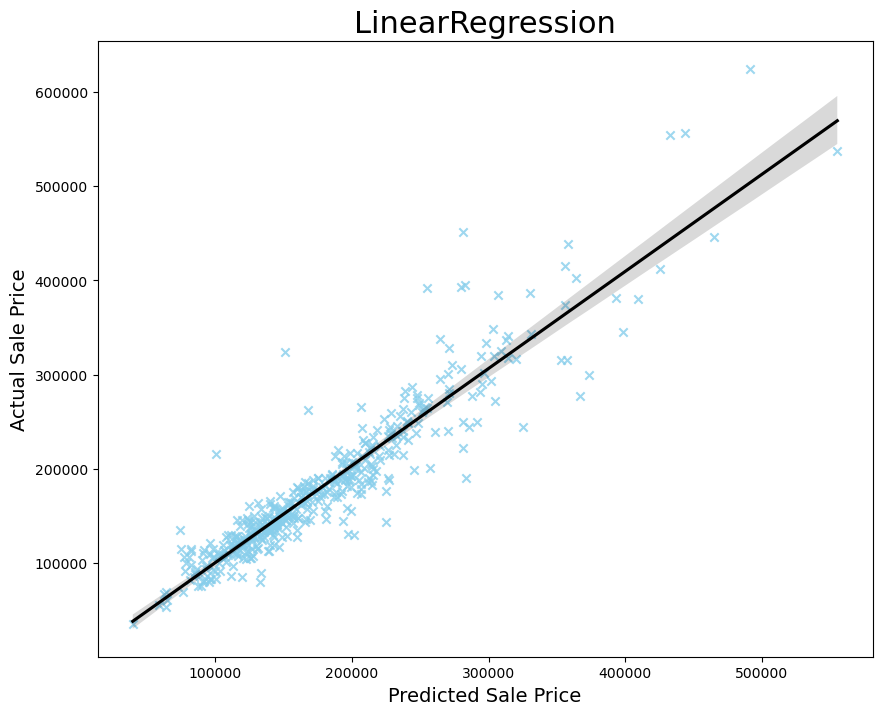


Lasso

Best params for Lasso: {'alpha': 0.0009, 'fit_intercept': True, 'max_iter': 20000, 'positive': False, 'selection': 'random'}

Train R²: 0.9193
Train MAE: 14564.86
Train MSE: 492559653.09
Train RMSE: 22193.68

Test R²: 0.8908
Test MAE: 16950.68
Test MSE: 743527474.19
Test RMSE: 27267.70



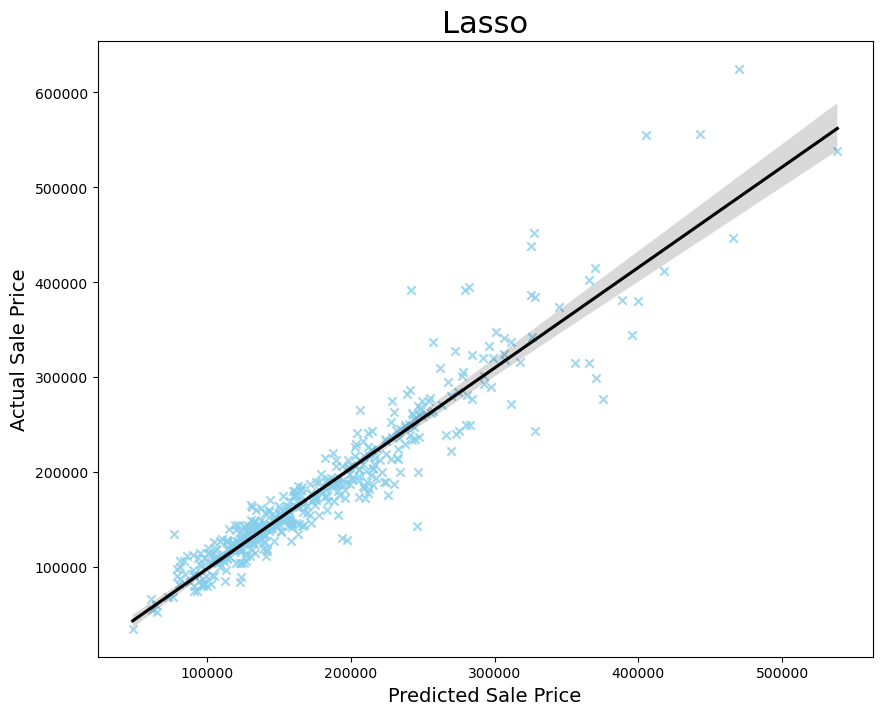


RandomForest

Best params for RandomForest: {'bootstrap': True, 'max_depth': 7, 'max_features': 0.8, 'max_samples': 0.68, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 170}

Train R²: 0.9235
Train MAE: 12255.22
Train MSE: 466935226.92
Train RMSE: 21608.68

Test R²: 0.8801
Test MAE: 17591.02
Test MSE: 816095009.49
Test RMSE: 28567.38



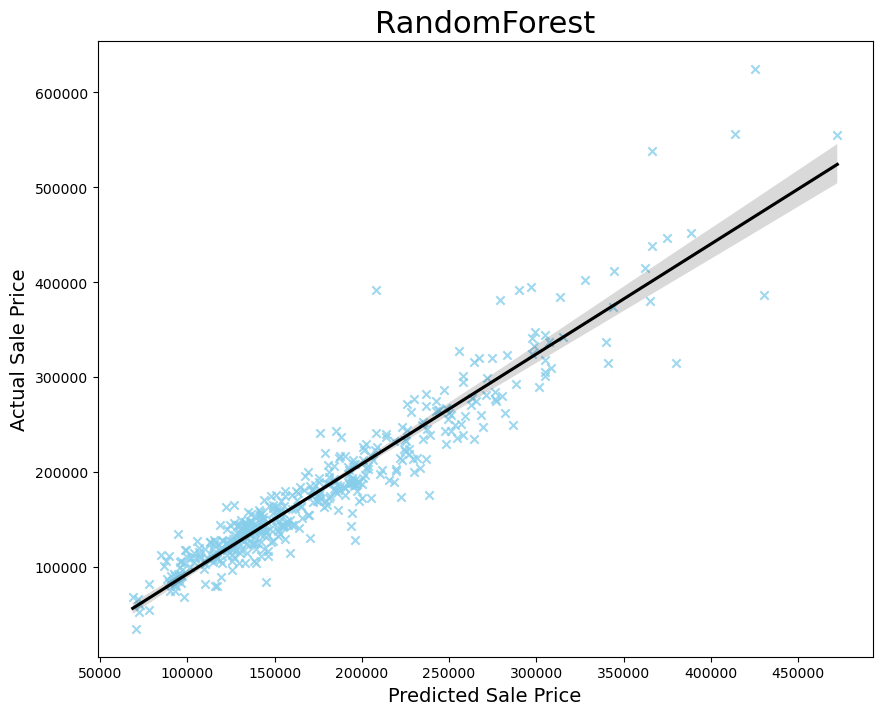


XGBoost

Best params for XGBoost: {'colsample_bytree': 0.46, 'gamma': 0.05, 'learning_rate': 0.08, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0.35, 'reg_lambda': 2, 'subsample': 0.55}

Train R²: 0.9473
Train MAE: 10954.93
Train MSE: 321644926.51
Train RMSE: 17934.46

Test R²: 0.9080
Test MAE: 16064.34
Test MSE: 626450083.57
Test RMSE: 25028.98



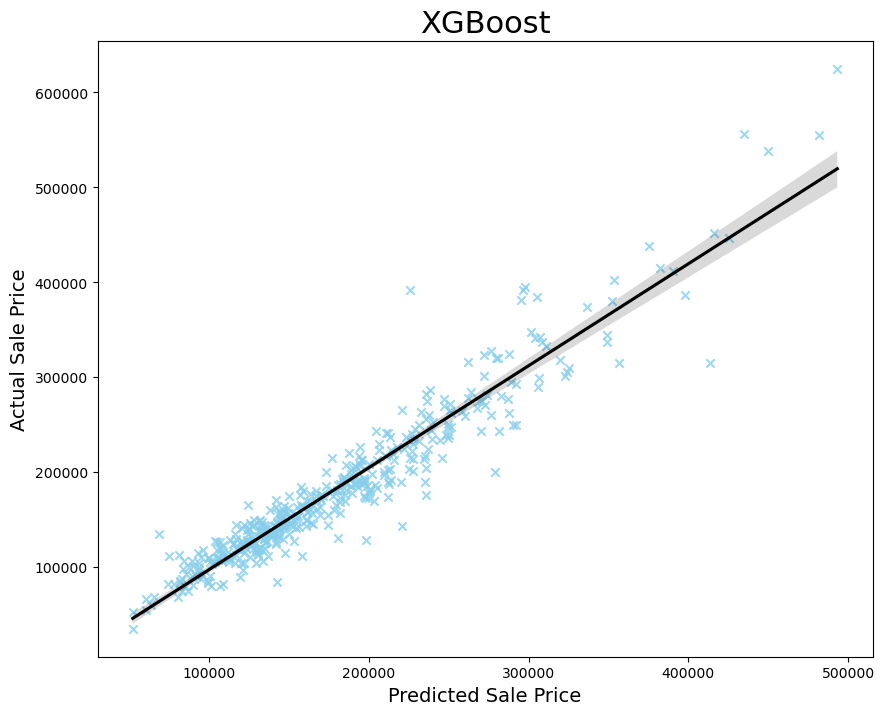


SVR

Best params for SVR: {'C': 0.95, 'epsilon': 0.06, 'gamma': 0.004, 'kernel': 'rbf'}

Train R²: 0.9472
Train MAE: 11826.81
Train MSE: 322114352.89
Train RMSE: 17947.54

Test R²: 0.9108
Test MAE: 15667.16
Test MSE: 606946551.19
Test RMSE: 24636.29



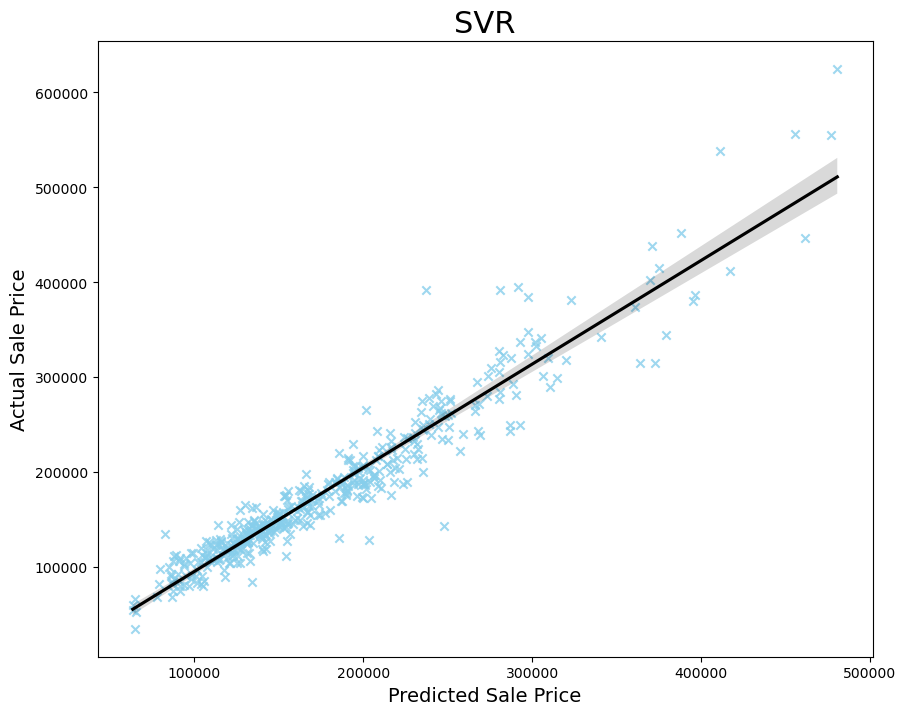

In [29]:
parameters = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            "fit_intercept": [True, False],
        }
    },
    
    "Lasso": {
        "model": Lasso(),
        "params": {
            "alpha": [0.0009],
            'max_iter': [20000],
            "selection": ['random'],
            "fit_intercept": [True],
            "positive": [False]
        }
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=0),
        "params": {
            "n_estimators": [170],
            "max_depth": [5,6,7],
            "min_samples_split": [3],
            "min_samples_leaf": [3],
            "max_features": [0.8],
            "bootstrap": [True],
            "max_samples": [0.68]
        }
    },
    
    "XGBoost": {
        "model": XGBRegressor(random_state=0),
        "params": {
            "learning_rate": [0.08],
             "n_estimators": [200],
             "max_depth": [6],
             'min_child_weight': [3],
             'gamma': [0.05],
             'subsample': [0.55],
             'colsample_bytree': [0.46],
             'reg_alpha': [0.35],
             'reg_lambda':[0.7,1,2]
        }
    },
    
     "SVR": {
         "model": SVR(),
         "params": {
             "kernel": ['rbf'],
             "C": [0.95],
             "epsilon": [0.06],
             "gamma": [0.004]
         }
     }
 }

best_models = {}
model_results = []

for name, mp in parameters.items():
    
    print(f"{name}")
    print()
    
    grid = GridSearchCV(mp["model"],
                        mp["params"],
                        cv=3,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1)
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_models[name] = best_model
    
    print(f"Best params for {name}: {grid.best_params_}")
    print()

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # --- Обратное логарифмирование ---
    MAX_EXP_INPUT = 700  # np.exp(709) ~= 8.2e+307 is close to float64 max

    y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
    y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))

    y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
    y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))
    
    train_mae = mean_absolute_error(y_train_exp, y_train_pred_exp)
    train_mse = mean_squared_error(y_train_exp, y_train_pred_exp)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_exp, y_train_pred_exp)
    
    print(f"Train R²: {train_r2:.4f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f'Train RMSE: {train_rmse:.2f}')
    print()

    test_mae = mean_absolute_error(y_test_exp, y_test_pred_exp)
    test_mse = mean_squared_error(y_test_exp, y_test_pred_exp)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test_exp, y_test_pred_exp)
    
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f'Test RMSE: {test_rmse:.2f}')
    print()

    model_results.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })
    
    plt.figure(figsize=(10,8))
    sns.regplot(x=y_test_pred_exp, y=y_test_exp, marker='x', color='skyblue', line_kws={'color':'black'})
    plt.xlabel('Predicted Sale Price', fontsize=14)
    plt.ylabel('Actual Sale Price', fontsize=14)
    plt.title(f"{name}", fontsize=22)
    plt.show()
    print()

In [30]:
def evaluate_model(model_name, model, params, X_train, y_train, X_test, y_test, model_results):
    print(f"\n{model_name} — начало анализа\n")

    # Настройка GridSearchCV
    grid = GridSearchCV(model, params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=3)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"Лучшие параметры для {model_name}: {grid.best_params_}\n")

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # --- Обратное логарифмирование ---
    MAX_EXP_INPUT = 700  
    y_train_pred_exp = np.expm1(np.clip(y_train_pred, a_max=MAX_EXP_INPUT, a_min=None))
    y_test_pred_exp = np.expm1(np.clip(y_test_pred, a_max=MAX_EXP_INPUT, a_min=None))
    y_train_exp = np.expm1(np.clip(y_train, a_max=MAX_EXP_INPUT, a_min=None))
    y_test_exp = np.expm1(np.clip(y_test, a_max=MAX_EXP_INPUT, a_min=None))

    # Вычисление метрик
    train_mae = mean_absolute_error(y_train_exp, y_train_pred_exp)
    train_mse = mean_squared_error(y_train_exp, y_train_pred_exp)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_exp, y_train_pred_exp)

    test_mae = mean_absolute_error(y_test_exp, y_test_pred_exp)
    test_mse = mean_squared_error(y_test_exp, y_test_pred_exp)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test_exp, y_test_pred_exp)

    # Вывод результатов
    print(f"Train R²: {train_r2:.4f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Train RMSE: {train_rmse:.2f}\n")

    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}\n")

    model_results.append({
        "Model": model_name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    plt.figure(figsize=(10,8))
    sns.regplot(x=y_test_pred_exp, y=y_test_exp, marker='x', color='skyblue', line_kws={'color':'black'})
    plt.xlabel('Предсказанная цена', fontsize=14)
    plt.ylabel('Фактическая цена', fontsize=14)
    plt.title(f"{model_name}", fontsize=22)
    plt.show()


GradientBoosting — начало анализа

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры для GradientBoosting: {'learning_rate': 0.02, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300, 'subsample': 0.7}

Train R²: 0.9579
Train MAE: 10878.68
Train MSE: 256890631.88
Train RMSE: 16027.81

Test R²: 0.9186
Test MAE: 15500.07
Test MSE: 553839008.16
Test RMSE: 23533.78



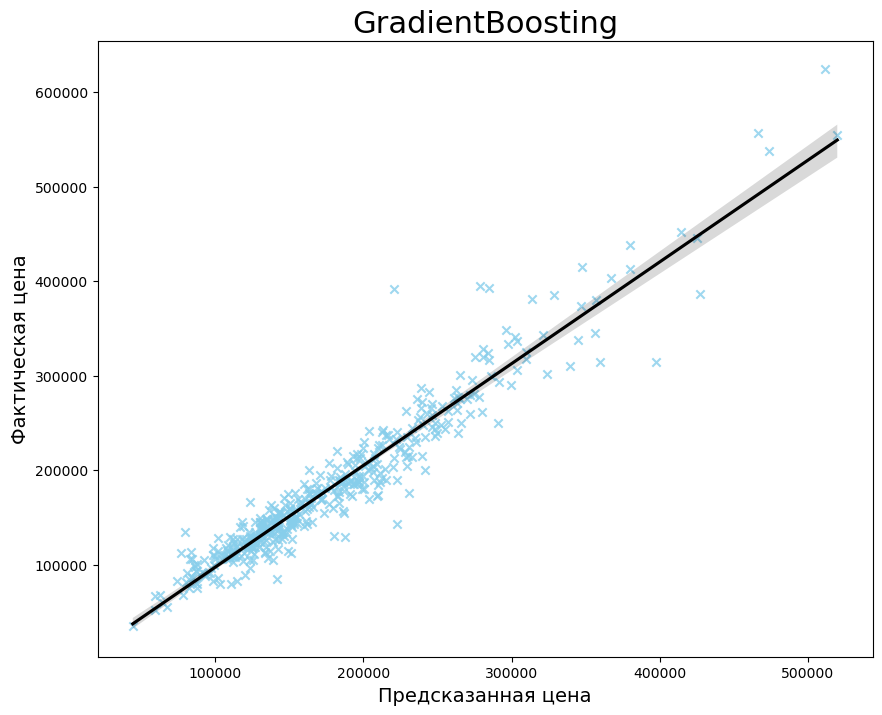

In [31]:
evaluate_model(
    model_name="GradientBoosting",
    model=GradientBoostingRegressor(),
    params={
        'n_estimators': [300],
        'learning_rate': [0.02],
        'max_depth': [3],
        'subsample': [0.7],
        'min_samples_leaf': [1, 3],
        'min_samples_split': [5, 8]
    },
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_results=model_results
)

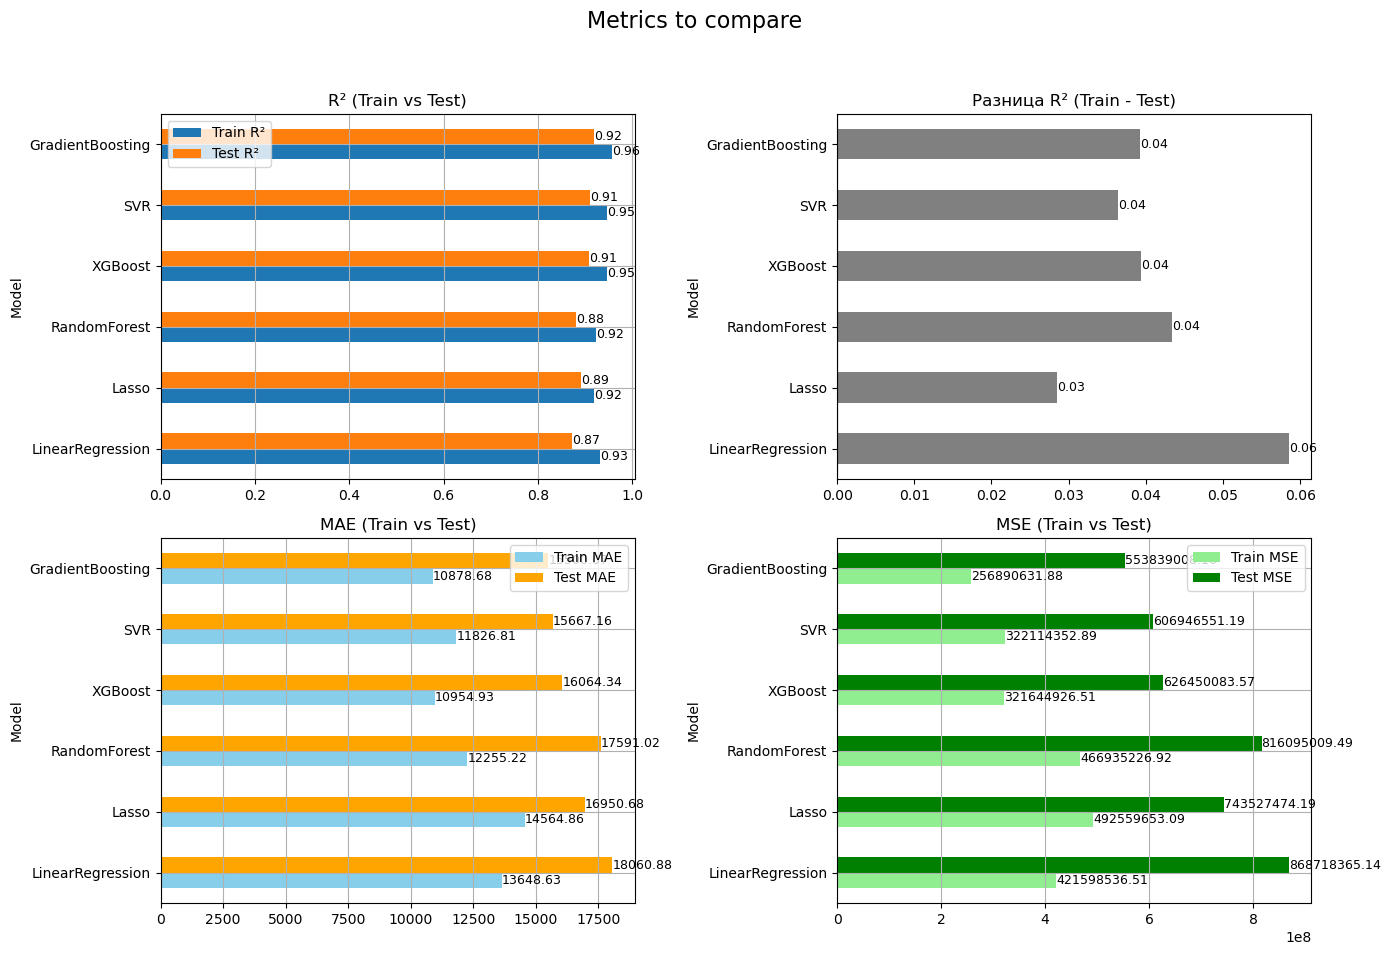

In [32]:
results = pd.DataFrame(model_results).set_index("Model")

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Metrics to compare", fontsize=16)

# R²
results[["Train R²", "Test R²"]].plot(kind="barh", ax=axs[0, 0], title="R² (Train vs Test)")
axs[0, 0].grid(True)

# Разница R²
(results["Train R²"] - results["Test R²"]).plot(kind="barh", ax=axs[0, 1], title="Разница R² (Train - Test)", color="grey")
axs[0, 1].axvline(0, color="black", linewidth=0.8)
axs[1, 1].grid(True)

# MAE
results[["Train MAE", "Test MAE"]].plot(kind="barh", ax=axs[1, 0], title="MAE (Train vs Test)", color=["skyblue", "orange"])
axs[1, 0].grid(True)

# MSE
results[["Train MSE", "Test MSE"]].plot(kind="barh", ax=axs[1, 1], title="MSE (Train vs Test)", color=["lightgreen", "green"])
axs[1, 1].grid(True)


# Функция для добавления подписей на горизонтальных столбцах
def add_values_on_bars_horizontal(ax):
    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width,                    # X - конец столбца
            p.get_y() + p.get_height() / 2.,  # Y - центр столбца
            f'{width:.2f}',           # Текст
            ha='left', va='center', fontsize=9
        )

# Добавляем подписи ко всем четырём графикам
for ax in axs.flatten():
    add_values_on_bars_horizontal(ax)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()